# ◆  Iris Flower Classification using Machine Learning
Oasis Infobyte Data Science Internship – Task 1


### Project Summary

This project builds an end-to-end machine learning pipeline to classify Iris flowers into Setosa, Versicolor, and Virginica using Scikit-learn. It includes data exploration, visualization, model training, and performance evaluation across multiple classification algorithms.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

### ◆ Use of libraries

* Pandas is used to load and manipulate tabular data.

* NumPy helps perform numerical computations.

* Matplotlib and Seaborn are used to create visualizations.

* Scikit-learn provides the Iris dataset and machine learning algorithms.

### Now, loading the dataset.
The Iris dataset contains measurements of 150 flowers belonging to three different species. It includes four numerical features that will be used to train the classification model.

In [ ]:
iris = load_iris()

df = pd.DataFrame( iris.data, columns=iris.feature_names)

df["species"] = iris.target

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,NaN
1,4.9,3.0,1.4,0.2,NaN
2,4.7,3.2,1.3,0.2,NaN
3,4.6,3.1,1.5,0.2,NaN
4,5.0,3.6,1.4,0.2,NaN


### ◆ Exploratory Data Analysis (EDA)
 We'll inspect the dataset before training the model.

In [ ]:
print("Shape:", df.shape)
print()

Shape: (150, 5)



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## ◆ Data Visualization

We'll explore how the flower species differ visually.

## ◆ Pairplot

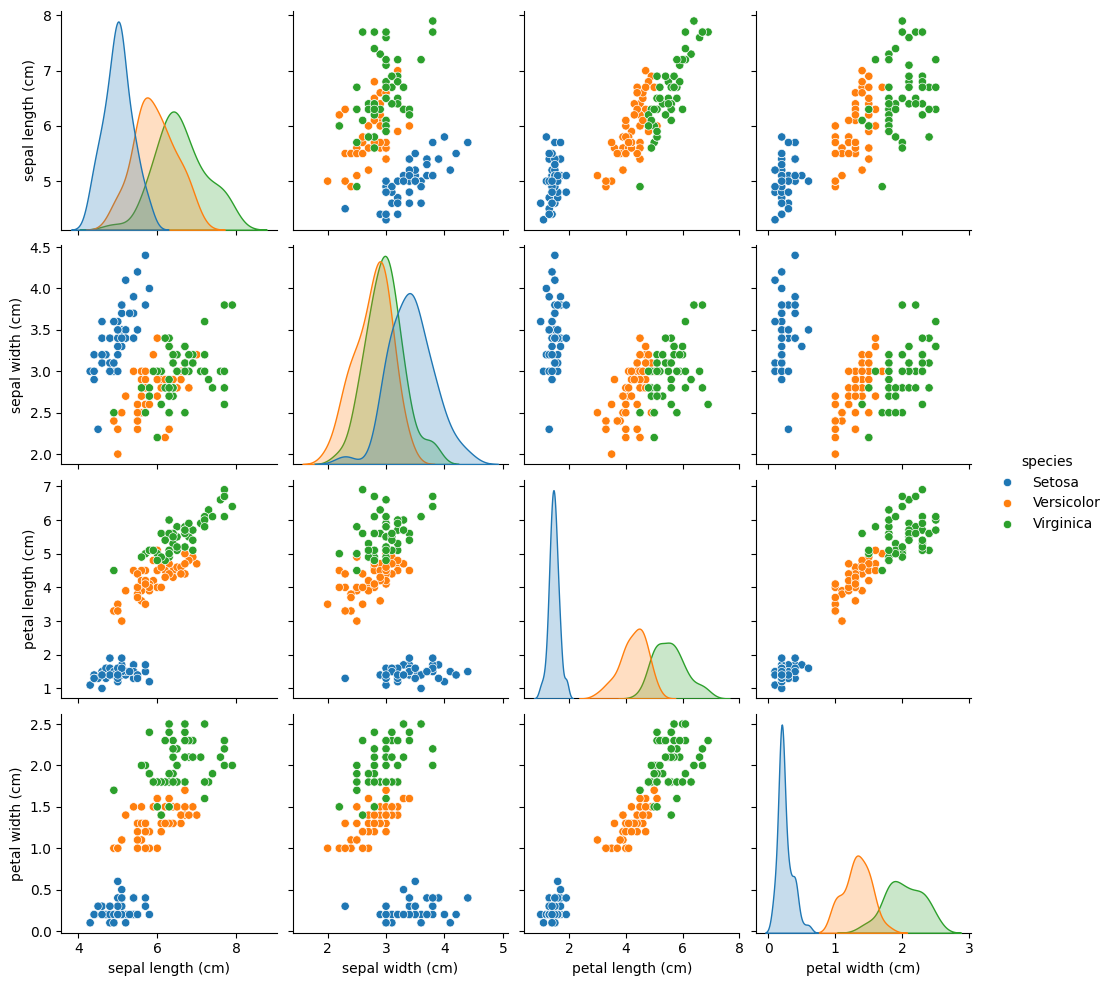

In [ ]:
sns.pairplot(df, hue="species")
plt.show()

## Pairplot Observation

* The pairplot shows relationships between all feature pairs.

## Key observations:

* Setosa is clearly separated from the other species.
* Versicolor and Virginica show slight overlap.
* Petal features appear to provide better separation than sepal features.

This creates one of the most important Iris graphs.

## ◆ Boxplot

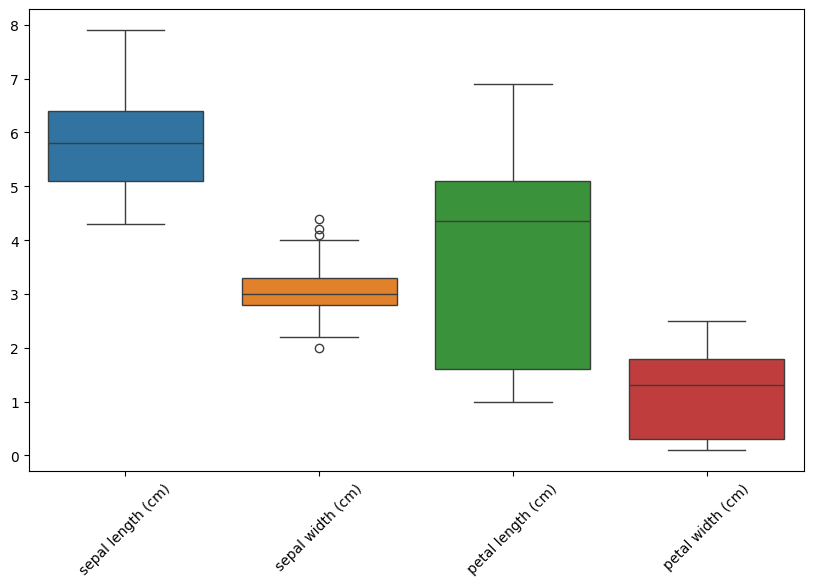

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)
plt.xticks(rotation=45)

plt.show()

## Boxplot Observation

* The boxplots compare the distribution of each feature across all flowers.

## Observations:

* Petal length and petal width vary significantly between species.
* Sepal measurements have more overlap.
* Only a few minor outliers are visible.

This helps identify feature distributions and possible outliers.

## ◆ Feature Correlation Heatmap

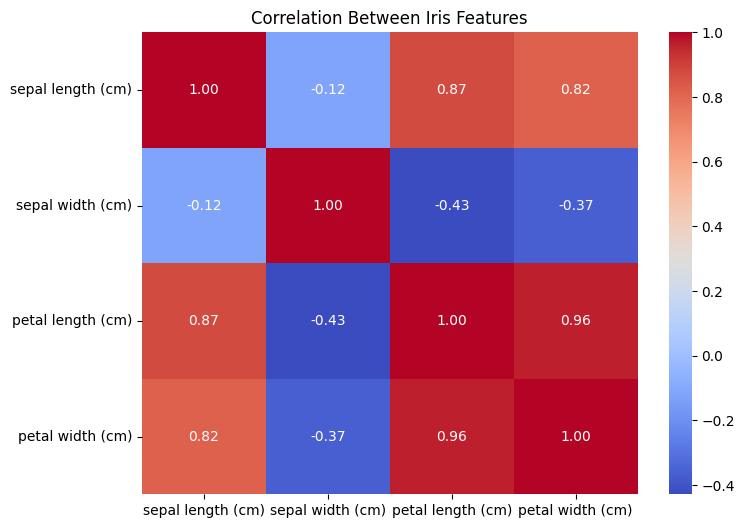

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Iris Features")
plt.show()

Petal length and petal width have a strong positive correlation, suggesting they carry similar information for distinguishing flower species.

## ◆ Feature Selection
We'll use the four flower measurements as input features and the species as the target variable.

In [ ]:
X = df.drop("species", axis=1)
y = df["species"]

print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    Setosa
1    Setosa
2    Setosa
3    Setosa
4    Setosa
Name: species, dtype: object


### What this does?

* X = input features (4 columns)

* y = output (flower species)

* axis=1 means remove the column named species.

## ◆ Train-Test Split

We'll split the data into 80% training and 20% testing.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (120, 4)
Testing samples: (30, 4)


## Applying StandardScaler
KNN is a distance-based algorithm, so features should be on a similar scale. StandardScaler standardizes the features to improve KNN's performance.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")

Training data scaled successfully.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

KNN performs better on standardized data because all features contribute equally to distance calculations.

In [ ]:
knn_unscaled = KNeighborsClassifier(n_neighbors=3)
knn_unscaled.fit(X_train, y_train)

acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))
acc_scaled = accuracy_score(y_test, knn.predict(X_test_scaled))

print("Unscaled Accuracy:", acc_unscaled)
print("Scaled Accuracy:", acc_scaled)

Unscaled Accuracy: 1.0
Scaled Accuracy: 1.0


## ◆ Train Model 1 — Logistic Regression

 Logistic Regression is a supervised classification algorithm that predicts class probabilities and assigns the most likely class. It serves as a strong baseline model for comparison.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## ◆ Train Model 2 — K-Nearest Neighbors
### K-Nearest Neighbors (KNN)

KNN classifies a flower by looking at the nearest neighboring flowers in the feature space. In this project, k = 3, meaning the prediction is based on the three closest samples.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

n_neighbors=3 means each prediction is based on the 3 nearest flowers.

## ◆ Train Model 3 — Decision Tree
### Decision Tree

The Decision Tree algorithm learns decision rules by repeatedly splitting the data based on feature values. Its structure is easy to interpret and helps identify important decision boundaries.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### ◆ Compare Model Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)
knn_acc = accuracy_score(y_test, knn_pred)
dt_acc = accuracy_score(y_test, dt_pred)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [lr_acc, knn_acc, dt_acc]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0
2,Decision Tree,1.0




The accuracy scores allow us to compare how well each algorithm classifies unseen flowers. The model with the highest accuracy will be selected for detailed evaluation.

## ◆ Prediction Probability

In [ ]:
prediction = knn.predict(sample)[0]
probability = knn.predict_proba(sample)[0]

print(f"Predicted Species: {prediction}")

for species, prob in zip(knn.classes_, probability):
    print(f"{species}: {prob*100:.2f}%")

Predicted Species: Setosa
Setosa: 100.00%
Versicolor: 0.00%
Virginica: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## ◆ Decision Tree Visualization

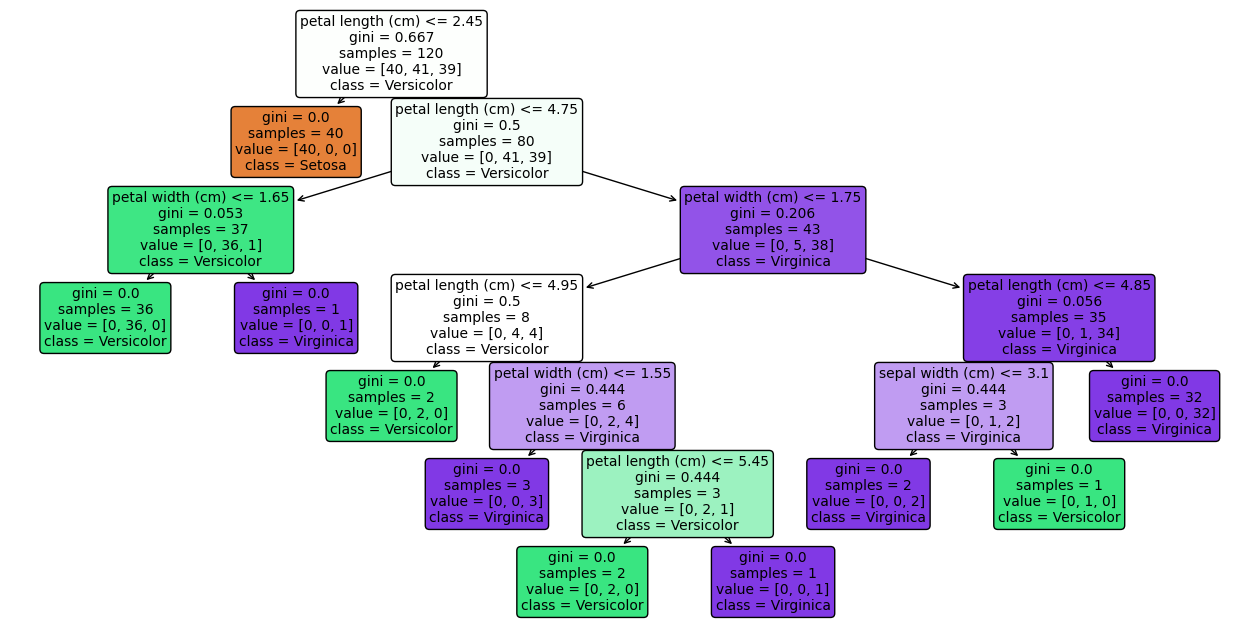

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True,
    rounded=True
)

plt.show()

## ◆ Cross-Validation Performance

In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Decision Tree": dt
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df

,Model,Mean Accuracy,Std Dev
0,Logistic Regression,0.973333,0.024944
1,KNN,0.966667,0.021082
2,Decision Tree,0.953333,0.033993


Although all three models achieved 100% accuracy on the test set, 5-fold cross-validation provides a more robust comparison across multiple train-test splits. KNN showed the highest average performance with low variation.

## ◆ Accuracy Comparison Chart

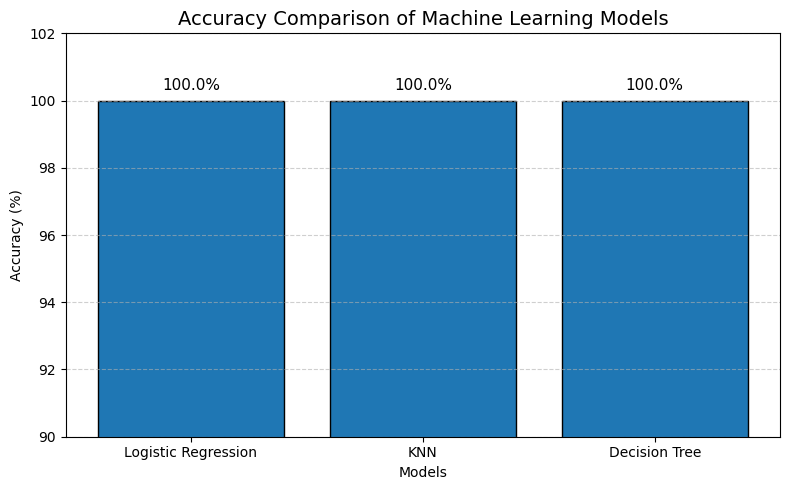

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    results["Model"],
    results["Accuracy"] * 100,
    edgecolor="black"
)

plt.title("Accuracy Comparison of Machine Learning Models", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 102)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add accuracy values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

## ◆ Accuracy Chart Interpretation

The bar chart provides a visual comparison of all three models. It makes it easier to identify the best-performing algorithm without relying only on numerical values.







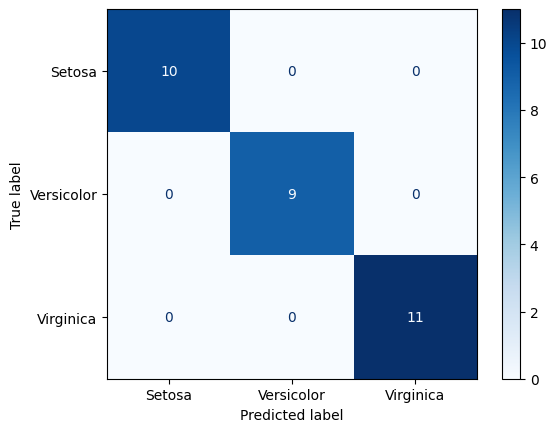

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

disp.plot(cmap="Blues")

plt.show()

## ◆ Confusion Matrix Interpretation

The confusion matrix shows how many flowers were classified correctly and where mistakes occurred. Most predictions fall along the diagonal, indicating that the model performs very well.

## ◆ Classification Report


The classification report provides:

* Precision – Correct positive predictions.

* Recall – Ability to identify actual instances.

* F1-score – Balance between precision and recall.

* High values across these metrics indicate strong classification performance.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## ◆ Prediction Demo

###  Enter flower measurements to predict the Iris species using the trained KNN model.

* This section demonstrates how the trained model can classify a new flower based on user-entered measurements. It simulates a real-world prediction scenario and makes the project more interactive.

In [ ]:
# These are  User inputs.

sepal_length = float(input("Enter Sepal Length (cm): "))
sepal_width = float(input("Enter Sepal Width (cm): "))
petal_length = float(input("Enter Petal Length (cm): "))
petal_width = float(input("Enter Petal Width (cm): "))

Enter Sepal Length (cm): 5.1
Enter Sepal Width (cm): 4.3
Enter Petal Length (cm): 1.2
Enter Petal Width (cm): 4.7


In [ ]:
# here, we will  create a sample with the entered values

sample = [[
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
]]

# Predict  Iris Species using KNN

prediction = knn.predict(sample)[0]

print("=" * 40)
print("Predicted Iris Species: ", prediction)
print("=" * 40)

Predicted Iris Species: Setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## ◆ Feature Importance Discussion
### ◆ Observation

* Petal length and petal width separate the flower species much more clearly than sepal measurements.

* Setosa is almost perfectly separated using petal features.

* Therefore, petal measurements are the most discriminative features.

## ◆ Conclusion
Three machine learning models were trained to classify Iris flowers. KNN achieved the highest performance on the test set. Petal length and petal width were the strongest predictors, while sepal measurements contributed less to distinguishing species. This demonstrates how supervised learning can accurately classify flowers using simple physical measurements.

## ◆ Key Learnings

* Performed complete Exploratory Data Analysis (EDA).

* Visualized feature distributions using Seaborn.

* Split data into training and testing sets correctly.

* Compared multiple machine learning algorithms.

* Evaluated models using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

* Built an interactive prediction demo using the trained model.